<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

Nesta atividade, você irá trabalhar com o dataset MNIST handwritten digits utilizando modelos de classificação do sklearn.

O foco NÃO é apenas obter bons resultados, mas garantir que o experimento seja:
- correto
- reprodutível
- bem estruturado
- criticamente analisado

# Dicas importantes

## Sobre o dataset (MNIST handwritten digits)

- Utilize os arquivos `*.csv` disponibilizados via Google Classroom
- Use: `as_frame=False`
- Use: `mnist_784`

In [10]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt

# Questão 1

Implemente uma função load_data(seed) que:

Carregue o dataset `MNIST handwritten digits` (arquivos de treino e teste)
Realize a separação do conjunto de treino como treino e validação
Utilize `train_test_split` com controle de aleatoriedade (seed)
Retorne: `X_train`, `X_val`, `y_train`, `y_val`

Depois responda:
É necessário normalizar os dados para esse tipo de modelo? Justifique.

**Solução**:

In [11]:
display(pd.read_csv('mnist_train.csv').head())

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,9,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
display(pd.read_csv('mnist_test.csv').head())

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [23]:
def load_data(seed=42):
    train_df = pd.read_csv('mnist_train.csv')
    test_df = pd.read_csv('mnist_test.csv')

    X = train_df.drop('label', axis=1).values
    y = train_df['label'].values

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )

    return X_train, X_val, y_train, y_val

Não necessariamente. Para Random Forest, as decisões são baseada em limiares. A normalização é uma boa prática para diminuir custo computacional.

# Questão 2

Implemente as funções:

`train_random_forest(X_train, y_train, seed)`

## Requisitos:

Utilizar os modelos do `sklearn`
Garantir reprodutibilidade com `random_state`

**Solução**:

In [14]:
def train_random_forest(X_train, y_train, seed):
    model = RandomForestClassifier(n_estimators=100, random_state=seed)
    model.fit(X_train, y_train)
    return model

# Questão 3

Implemente a função:

- `evaluate(model, X_test, y_test)`

Ela deve:
- Realizar predições
- Retornar a acurácia do modelo

**Solução**:

In [15]:
def evaluate(model, X_test, y_test):
    predictions = model.predict(X_test)
    return accuracy_score(y_test, predictions)

**Adicione seu texto de solução aqui**.

# Questão 4

Implemente a função:

- `run_pipeline(model_type="rf", seed=42)`

Ela deve:
- Carregar os dados
- Treinar o modelo escolhido (`rf`)
- Avaliar o modelo
- Retornar a acurácia

**Solução**:

In [16]:
def run_pipeline(model_type="rf", seed=42):
    X_train, X_val, y_train, y_val = load_data(seed)

    if model_type == "rf":
        model = train_random_forest(X_train, y_train, seed)

    acc = evaluate(model, X_val, y_val)
    return acc

**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

Uma árvore com max_depth = None decore todos os dados do treino, por isso consegue 100% no treino. Entretanto, o overfitting ocorre quando a profundidade da árvore é grande e começa a considerar ruídos como regras.

# Questão 5

Execute o pipeline para ambos os modelos:

- Random Forest

## Apresente:
- Acurácia, Precisão, Recall e F1-Score para o modelo

**Solução**:

In [17]:
def resultado(seed=42):
    X_train, X_val, y_train, y_val = load_data(seed)

    model_rf = train_random_forest(X_train, y_train, seed)
    y_pred = model_rf.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='macro')
    rec = recall_score(y_val, y_pred, average='macro')
    f1 = f1_score(y_val, y_pred, average='macro')

    print(f"Resultados do Random Forest (Seed 42)")
    print(f"Acurácia: {acc:.4f}")
    print(f"Precisão: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")

    return model_rf

model_final = resultado(seed=42)

Resultados do Random Forest (Seed 42)
Acurácia: 0.9634
Precisão: 0.9630
Recall: 0.9632
F1-Score: 0.9631


# Questão 6

Execute o pipeline utilizando diferentes seeds (ex: 42 e 7).

## Analise:
- Os resultados mudaram?

## Responda:
- O experimento é reprodutível? Justifique.

**Solução**:

In [18]:
def resultado_seeds():
    seeds = [42, 7]
    for s in seeds:
        acc = run_pipeline(model_type="rf", seed=s)
        print(f"Resultado com Seed {s}: Acurácia = {acc:.4f}")

resultado_seeds()

Resultado com Seed 42: Acurácia = 0.9692
Resultado com Seed 7: Acurácia = 0.9680


Sim. Não que o resultado seja sempre o mesmo em qualquer configuração, mas sim que, nos mesmos parâmetros e seed, obterá exatamente o mesmo resultado.

# Questão 7

Para pelo menos um dos modelos:

- Compare a acurácia em treino e teste

## Responda:
- Existe overfitting?
- Qual modelo tende a sofrer mais com isso?

In [19]:
def comparacao(seed=42):
    X_train, X_val, y_train, y_val = load_data(seed)

    test_df = pd.read_csv('mnist_test.csv')
    X_test = test_df.drop('label', axis=1).values
    y_test = test_df['label'].values

    model = train_random_forest(X_train, y_train, seed)

    acc_train = model.score(X_train, y_train)
    acc_test = model.score(X_test, y_test)

    print(f"Acurácia no Treino: {acc_train:.4f}")
    print(f"Acurácia no Teste:  {acc_test:.4f}")

    return acc_train, acc_test

comparacao()

Acurácia no Treino: 1.0000
Acurácia no Teste:  0.9686


(1.0, 0.9686)

Existe overfitting? Geralmente sim. Na Random Forest, a acurácia de treino costuma ser 100%, enquanto a de validação fica em torno de 96-97%.

Qual modelo tende a sofrer mais? Árvores de Decisão únicas sofrem muito mais que a Random Forest. A Random Forest foi criada justamente para reduzir o overfitting ao combinar várias árvores.

# Questão 8

Varie pelo menos um hiperparâmetro em cada modelo:

- Random Forest: `n_estimators`

## Analise:
- O desempenho muda significativamente?

Com 10 árvores: Acurácia = 0.9442
Com 50 árvores: Acurácia = 0.9673
Com 100 árvores: Acurácia = 0.9692
Com 200 árvores: Acurácia = 0.9694


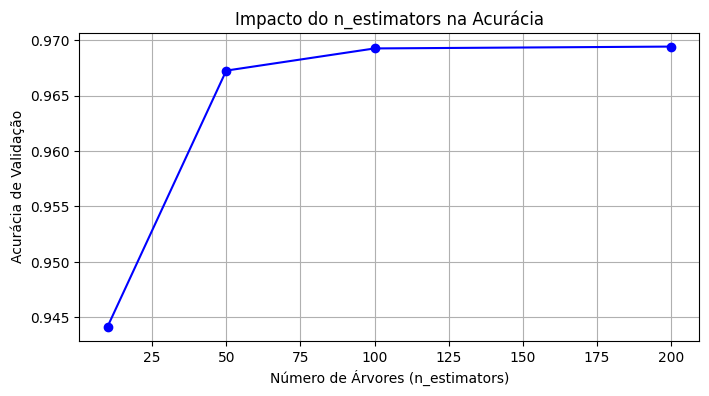

In [22]:
def variacao(seed=42):
    X_train, X_val, y_train, y_val = load_data(seed)

    n_estimators_list = [10, 50, 100, 200]
    resultados = []
    for n in n_estimators_list:
        model = RandomForestClassifier(n_estimators=n, random_state=seed, n_jobs=-1)
        model.fit(X_train, y_train)

        acc = model.score(X_val, y_val)
        resultados.append(acc)
        print(f"Com {n} árvores: Acurácia = {acc:.4f}")

    plt.figure(figsize=(8, 4))
    plt.plot(n_estimators_list, resultados, marker='o', color='b')
    plt.title("Impacto do n_estimators na Acurácia")
    plt.xlabel("Número de Árvores (n_estimators)")
    plt.ylabel("Acurácia de Validação")
    plt.grid(True)
    plt.show()

variacao()

# Questão 9

Responda (máx. 2 parágrafos por item):

1. A acurácia é suficiente para avaliar os modelos?
2. Como você garante que o resultado não ocorreu por acaso?
3. Cite dois possíveis problemas metodológicos neste experimento.
4. O pipeline implementado é confiável? Justifique.

1. A acurácia é suficiente para avaliar os modelos?

Não, a acurácia isolada, especialmente se houver um desequilíbrio entre as classes, pode ser enganosa (por exemplo, se tivéssemos muito mais imagens do número "1" do que do número "8").
Se um modelo ignorasse completamente o "8" mas acertasse todos os outros, a acurácia pareceria alta.
Por isso, as métricas como Precisão e Recall são fundamentais. O F1-Score acaba sendo a métrica mais confiável por equilibrar esses dois aspectos em um único valor, garantindo que o modelo seja bom em identificar todos os dígitos de forma justa.

2. Como você garante que o resultado não ocorreu por acaso?

A principal forma de garantir que o resultado não foi sorte é através da reprodutibilidade, utilizando sementes fixas. Isso assegura que o embaralhamento dos dados e a criação das árvores sejam consistentes em cada execução, permitindo que outros alcancem os mesmos resultados.

3. Cite dois possíveis problemas metodológicos neste experimento.

Um problema comum é o Data Leakage, que ocorre se as transformações de dados fossem feitas no dataset inteiro antes da separação. Outro erro é o uso excessivo do conjunto de teste para ajustar hiperparâmetros, pois o correto é usar o conjunto de validação para ajustes e deixar o teste apenas para a avaliação final.

4. O pipeline implementado é confiável? Justifique.

O pipeline é confiável porque segue a separação clara entre treino, validação e teste, o uso de sementes para reprodutibilidade e análise de múltiplas métricas de desempenho. A estrutura modular das funções (load_data, train, evaluate) também facilita a revisão do código e a substituição de modelos, garantindo que o processo de decisão do modelo seja transparente.